# 리텐션·코호트 분석 기준 설정을 위한 EDA


# 사용 데이터
전처리 코드를 통해 전처리한 데이터
- `01_user_profile_preprocessed.csv`
- `02_event_log_preprocessed.csv`


## 진행 흐름
1. 리텐션 분석 전처리
2. 리텐션 분석 전 기준 지정
3. 리텐션 분석 가능 범위

## 이번 EDA에서 정할 기준
1. Day 0 기준 설정
2. 활성 유저 판단 이벤트 설정
3. 알림 이벤트 제외 기준 확인
4. 로그 수집 장애 기간 플래그 확인
5. D0/D3/D7/D30 목표일 산정 가능 여부 확인
6. 월별 가입 코호트 기준 분석 가능 범위 확인


> 이번 단계에서는 실제 리텐션율을 계산하지 않습니다.  
> 먼저 **어떤 기준으로 리텐션을 계산할지**와 **어떤 구간을 주의해서 해석해야 하는지**를 정리합니다.

# 선 결론

## 이번 EDA에서 확정할 핵심 기준

| 구분 | 기준 |
|---|---|
| Day 0 | 가입일 |
| 활성 유저 | 해당 일자에 `앱실행` 이벤트가 존재하는 사용자 |
| 제외 이벤트 | `알림수신`, `알림오픈`은 앱 밖 OS 알림 이벤트이므로 활성 판단에서 제외 |
| 로그 수집 장애 기간 | 2025-03-10 ~ 2025-03-14 |
| 장애 기간 처리 | 삭제하지 않고 별도 플래그로 관리 |
| 코호트 기준 | 가입월(`signup_month`) |
| 리텐션 목표일 | D0, D3, D7, D30 |

## 추가 계산 기준

| 구분 | 기준 |
|---|---|
| 리텐션 판정 방식 | 정확히 N일째 되는 날짜에 `앱실행` 이벤트가 있는지 확인 |
| 사용자 중복 처리 | 목표일에 앱실행이 여러 번 있어도 사용자 1명은 1명으로 계산 |
| 관측 기간 밖 목표일 | 리텐션 산정 불가로 분리 |
| 장애 기간 목표일 | 삭제하지 않고 플래그로 관리 후 해석 시 주의 |

# 0. 라이브러리 호출 및 기본 설정

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

In [2]:
# 1. 프로젝트 경로 설정
# 프로젝트 최상위 폴더입니다.
# 본인 PC에서 GitHub 프로젝트가 있는 위치로 바꾸면 됩니다.
ROOT = Path(r"C:\Users\joon5\Documents\github\Anti-Churn-Committee")

# 원본 데이터가 들어있는 폴더
DATA_PROCESSED_DIR = ROOT / "data" / "processed"


# 원본 파일명입니다.
# data/raw 폴더 안에 이 이름으로 파일이 있어야 합니다.
USER_PROFILE_FILE = "01_user_profile_preprocessed.csv"
EVENT_LOG_FILE = "02_event_log_preprocessed.csv"

# 실제로 읽어올 파일 경로를 만듭니다.
USER_PROFILE_PATH = DATA_PROCESSED_DIR / USER_PROFILE_FILE
EVENT_LOG_PATH = DATA_PROCESSED_DIR / EVENT_LOG_FILE

print("USER_PROFILE_PATH:", USER_PROFILE_PATH)
print("EVENT_LOG_PATH   :", EVENT_LOG_PATH)
print("저장 폴더        :", DATA_PROCESSED_DIR)

user_profile = pd.read_csv(USER_PROFILE_PATH)
event_log = pd.read_csv(EVENT_LOG_PATH)

print("user_profile shape:", user_profile.shape)
print("event_log shape:", event_log.shape)

display(user_profile.head())
display(event_log.head())

USER_PROFILE_PATH: C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\01_user_profile_preprocessed.csv
EVENT_LOG_PATH   : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\02_event_log_preprocessed.csv
저장 폴더        : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed
user_profile shape: (12500, 23)
event_log shape: (1757262, 11)


,user_id,signup_date,signup_channel,device,notification_agreed,notification_changed_date,signup_day,signup_month,signup_weekday,first_event_time,first_event_elapsed_hours,first_app_launch_time,app_launch_elapsed_hours,onboarding_completed_time,onboarding_elapsed_hours,app_launch_to_onboarding_hours,is_onboarding_completed,event_count_total,avg_events_per_session,is_signup_log_issue_period,is_no_event_user,is_notification_changed,is_first_event_before_signup
0,U0000001,2025-01-25,오가닉,iOS,True,NaN,2025-01-25,2025-01,토,2025-01-25 07:25:45,7.429167,2025-01-25 07:25:45,7.429167,2025-01-25 07:26:15,7.437500,0.008333,True,515,2.07,False,False,False,False
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24,2025-05-06,2025-05,화,2025-05-06 16:23:12,16.386667,2025-05-06 16:23:12,16.386667,NaN,NaN,NaN,False,55,2.62,False,False,True,False
2,U0000003,2025-05-14,오가닉,iOS,False,NaN,2025-05-14,2025-05,수,2025-05-14 11:09:58,11.166111,2025-05-14 11:09:58,11.166111,NaN,NaN,NaN,False,3,1.50,False,False,False,False
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaN,2025-02-23,2025-02,일,2025-02-23 07:15:35,7.259722,2025-02-23 07:15:35,7.259722,NaN,NaN,NaN,False,89,1.79,False,False,False,False
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaN,2025-02-18,2025-02,화,2025-02-18 12:50:01,12.833611,2025-02-18 12:52:37,12.876944,2025-02-18 12:53:07,12.885278,0.008333,True,442,1.85,False,False,False,False


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False


# 날짜 컬럼 정리

In [3]:
# 사용자 프로필 날짜 컬럼 정리
user_profile["signup_date"] = pd.to_datetime(user_profile["signup_date"], errors="coerce")
user_profile["signup_day"] = pd.to_datetime(user_profile["signup_day"], errors="coerce").dt.normalize()
user_profile["signup_month"] = user_profile["signup_day"].dt.to_period("M").astype(str)

if "notification_changed_date" in user_profile.columns:
    user_profile["notification_changed_date"] = pd.to_datetime(
        user_profile["notification_changed_date"],
        errors="coerce"
    )

# 이벤트 로그 날짜 컬럼 정리
event_log["event_time"] = pd.to_datetime(event_log["event_time"], errors="coerce")
event_log["event_date"] = pd.to_datetime(event_log["event_date"], errors="coerce").dt.normalize()
event_log["event_month"] = event_log["event_date"].dt.to_period("M").astype(str)

# 분석 기준
issue_start = pd.Timestamp("2025-03-10")    # 로그 수집 장애 시작일
issue_end = pd.Timestamp("2025-03-14")      # 로그 수집 장애 종료일
retention_days_list = [0, 3, 7, 30]         # 리덴션 날짜

print("사용자 프로필 날짜 범위")
print("가입일 최소:", user_profile["signup_day"].min())
print("가입일 최대:", user_profile["signup_day"].max())

print("\n이벤트 로그 날짜 범위")
print("이벤트일 최소:", event_log["event_date"].min())
print("이벤트일 최대:", event_log["event_date"].max())

print("\n분석 기준")
print("로그 수집 장애 시작일:", issue_start)
print("로그 수집 장애 종료일:", issue_end)
print("리덴션 날짜:", retention_days_list)

사용자 프로필 날짜 범위
가입일 최소: 2025-01-01 00:00:00
가입일 최대: 2025-05-26 00:00:00

이벤트 로그 날짜 범위
이벤트일 최소: 2025-01-01 00:00:00
이벤트일 최대: 2025-06-30 00:00:00

분석 기준
로그 수집 장애 시작일: 2025-03-10 00:00:00
로그 수집 장애 종료일: 2025-03-14 00:00:00
리덴션 날짜: [0, 3, 7, 30]


# 기준 1: Day 0 기준 설정

리텐션 분석에서 Day 0은 사용자의 기준 시작일을 의미한다.  
Day 0을 어디로 설정하느냐에 따라 리텐션 분석의 해석 범위가 달라진다.

이번 분석에서는 아래 4가지 후보를 비교한다.

| Day 0 후보 | 의미 | 장점 | 주의점 |
|---|---|---|---|
| 가입일 | 사용자가 서비스에 가입한 날짜 | 전체 신규 가입자 기준으로 리텐션을 볼 수 있음 | 가입만 하고 앱을 실행하지 않은 사용자도 포함됨 |
| 첫 앱실행일 | 사용자가 처음 앱을 실행한 날짜 | 실제 앱 사용 시작 이후의 리텐션을 볼 수 있음 | 가입 후 앱을 실행하지 않은 사용자가 제외됨 |
| 온보딩 완료일 | 사용자가 온보딩을 완료한 날짜 | 온보딩 이후 유지율을 보기 좋음 | 온보딩을 완료하지 못한 사용자가 제외되어 리텐션이 높게 보일 수 있음 |
| 첫 핵심기능 사용일 | 기록/챌린지 등 핵심 기능을 처음 사용한 날짜 | 기능 경험 이후 잔존을 보기 좋음 | 적극적인 사용자만 남아 선택 편향이 커질 수 있음 |

따라서 각 후보별로 기준일을 만들 수 있는 사용자 수와 가입일 이후 기준일까지 걸린 시간을 비교한 뒤,  
이번 과제의 목적에 가장 적합한 Day 0 기준을 선택한다.

## 1-1. 가입월별 사용자 수 확인

In [4]:
# Day 0 후보군 비교

# 후보 1. 가입일
day0_signup = user_profile[["user_id", "signup_day"]].copy()
day0_signup = day0_signup.rename(columns={"signup_day": "day0_date"})
day0_signup["day0_type"] = "가입일"

# 후보 2. 첫 앱실행일
first_app_launch = (
    event_log[event_log["event_type"].eq("앱실행")]
    .groupby("user_id", as_index=False)
    .agg(day0_date=("event_date", "min"))
)
first_app_launch["day0_type"] = "첫 앱실행일"

# 후보 3. 온보딩 완료일
first_onboarding = (
    event_log[event_log["event_type"].eq("온보딩_완료")]
    .groupby("user_id", as_index=False)
    .agg(day0_date=("event_date", "min"))
)
first_onboarding["day0_type"] = "온보딩 완료일"

# 후보 4. 첫 핵심기능 사용일
core_events = [
    "수면기록",
    "운동기록",
    "마음챙김",
    "식단기록",
    "챌린지_탐색",
    "챌린지참여"
]

first_core_event = (
    event_log[event_log["event_type"].isin(core_events)]
    .groupby("user_id", as_index=False)
    .agg(day0_date=("event_date", "min"))
)
first_core_event["day0_type"] = "첫 핵심기능 사용일"

# 후보군 통합
day0_candidates = pd.concat(
    [
        day0_signup,
        first_app_launch,
        first_onboarding,
        first_core_event
    ],
    ignore_index=True
)

# 가입일과 비교하기 위해 signup_day 결합
day0_candidates = day0_candidates.merge(
    user_profile[["user_id", "signup_day"]],
    on="user_id",
    how="left"
)

# 가입 후 기준일까지 걸린 일수
day0_candidates["days_from_signup"] = (
    day0_candidates["day0_date"] - day0_candidates["signup_day"]
).dt.days

display(day0_candidates.head())

,user_id,day0_date,day0_type,signup_day,days_from_signup
0,U0000001,2025-01-25,가입일,2025-01-25,0
1,U0000002,2025-05-06,가입일,2025-05-06,0
2,U0000003,2025-05-14,가입일,2025-05-14,0
3,U0000004,2025-02-23,가입일,2025-02-23,0
4,U0000005,2025-02-18,가입일,2025-02-18,0


In [5]:
# Day 0 후보별 적용 가능 사용자 수 비교

total_user_count = user_profile["user_id"].nunique()

day0_candidate_summary = (
    day0_candidates
    .groupby("day0_type", as_index=False)
    .agg(
        기준일_생성_사용자수=("user_id", "nunique"),
        가입후_기준일까지_평균일수=("days_from_signup", "mean"),
        가입후_기준일까지_중앙값=("days_from_signup", "median"),
        가입후_기준일까지_최대일수=("days_from_signup", "max")
    )
)

day0_candidate_summary["전체_가입자수"] = total_user_count

day0_candidate_summary["기준일_없는_사용자수"] = (
    day0_candidate_summary["전체_가입자수"]
    - day0_candidate_summary["기준일_생성_사용자수"]
)

day0_candidate_summary["기준일_생성률"] = (
    day0_candidate_summary["기준일_생성_사용자수"]
    / day0_candidate_summary["전체_가입자수"]
    * 100
).round(2)

day0_candidate_summary["가입후_기준일까지_평균일수"] = (
    day0_candidate_summary["가입후_기준일까지_평균일수"].round(2)
)

day0_type_order = [
    "가입일",
    "첫 앱실행일",
    "온보딩 완료일",
    "첫 핵심기능 사용일"
]

day0_candidate_summary["day0_type"] = pd.Categorical(
    day0_candidate_summary["day0_type"],
    categories=day0_type_order,
    ordered=True
)

day0_candidate_summary = (
    day0_candidate_summary
    .sort_values("day0_type")
    [[
        "day0_type",
        "전체_가입자수",
        "기준일_생성_사용자수",
        "기준일_없는_사용자수",
        "기준일_생성률",
        "가입후_기준일까지_평균일수",
        "가입후_기준일까지_중앙값",
        "가입후_기준일까지_최대일수"
    ]]
)

display(day0_candidate_summary)

,day0_type,전체_가입자수,기준일_생성_사용자수,기준일_없는_사용자수,기준일_생성률,가입후_기준일까지_평균일수,가입후_기준일까지_중앙값,가입후_기준일까지_최대일수
0,가입일,12500,12500,0,100.00,0.00,0.0,0
2,첫 앱실행일,12500,12447,53,99.58,0.03,0.0,5
1,온보딩 완료일,12500,5719,6781,45.75,0.00,0.0,0
3,첫 핵심기능 사용일,12500,12275,225,98.20,0.10,0.0,6


### 기준일 생성률

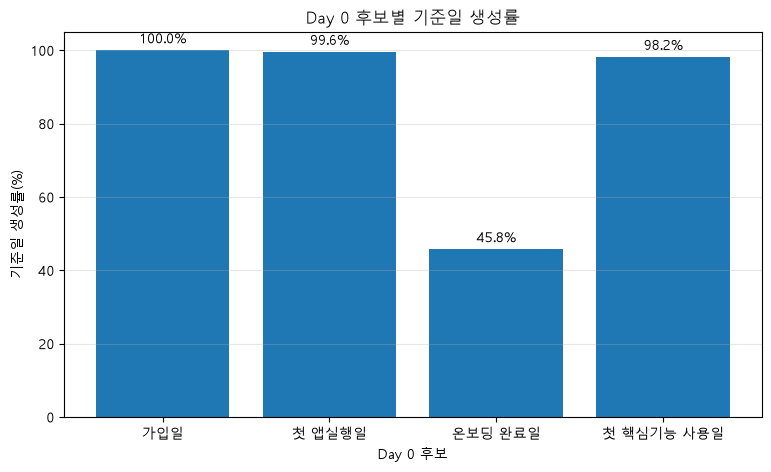

In [6]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    day0_candidate_summary["day0_type"].astype(str),
    day0_candidate_summary["기준일_생성률"]
)

plt.title("Day 0 후보별 기준일 생성률")
plt.xlabel("Day 0 후보")
plt.ylabel("기준일 생성률(%)")
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in day0_candidate_summary["기준일_생성률"]],
    padding=3
)

plt.show()

### 그래프 해석: Day 0 후보별 기준일 생성률

가입일은 전체 사용자에게 적용 가능하다.     
첫 앱실행일과 첫 핵심기능 사용일도 대부분의 사용자에게 기준일을 만들 수 있다.   
온보딩 완료일은 기준일 생성률이 낮아, 온보딩을 완료하지 못한 사용자가 분석에서 제외

### 기준일 없는 사용자 수

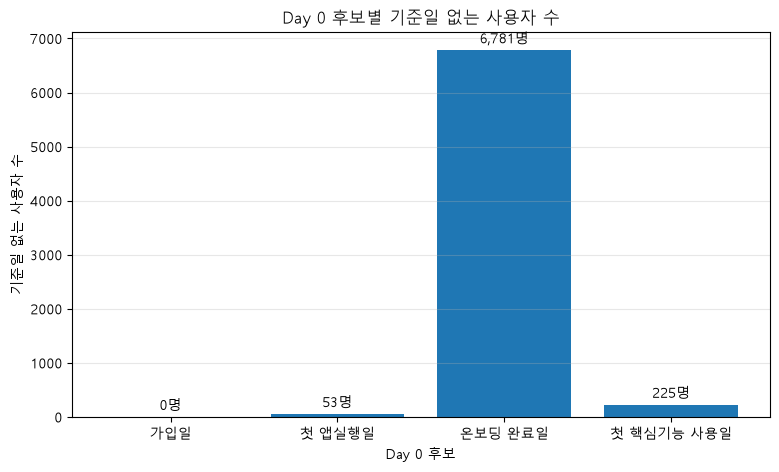

In [7]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    day0_candidate_summary["day0_type"].astype(str),
    day0_candidate_summary["기준일_없는_사용자수"]
)

plt.title("Day 0 후보별 기준일 없는 사용자 수")
plt.xlabel("Day 0 후보")
plt.ylabel("기준일 없는 사용자 수")
plt.grid(axis="y", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:,}명" for value in day0_candidate_summary["기준일_없는_사용자수"]],
    padding=3
)

plt.show()

### 그래프 해석: Day 0 후보별 기준일 없는 사용자 수

가입일 기준은 제외되는 사용자가 없으나,     
첫 앱실행일과 첫 핵심기능 사용일은 제외 사용자가 적은 편이다.       
온보딩 완료일은 기준일이 없는 사용자가 많아, 메인 리텐션 기준으로 사용하면 분석 대상이 크게 줄어든다.

### 가입 후 기준일까지 평균 소요 일수

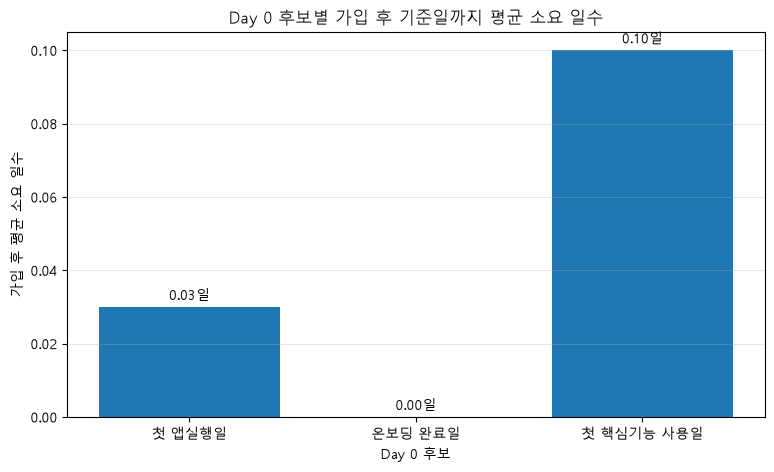

In [8]:
day0_delay_summary = day0_candidate_summary[
    day0_candidate_summary["day0_type"].astype(str).ne("가입일")
].copy()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    day0_delay_summary["day0_type"].astype(str),
    day0_delay_summary["가입후_기준일까지_평균일수"]
)

plt.title("Day 0 후보별 가입 후 기준일까지 평균 소요 일수")
plt.xlabel("Day 0 후보")
plt.ylabel("가입 후 평균 소요 일수")
plt.grid(axis="y", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:.2f}일" for value in day0_delay_summary["가입후_기준일까지_평균일수"]],
    padding=3
)

plt.show()

### 그래프 해석: 가입 후 기준일까지 평균 소요 일수
첫 앱실행일과 첫 핵심기능 사용일은 대부분 가입 직후에 발생한다.     
온보딩 완료일도 평균 소요 일수는 짧지만, 기준일을 만들 수 있는 사용자 자체가 적다.

따라서 Day 0 기준을 비교할 때는 소요 일수보다 **전체 사용자에게 적용 가능한지**를 더 중요하게 봐야 한다.

### 결론

### Day 0 기준 결정

이번 리텐션 분석의 Day 0은 **가입일**로 설정한다.

본 과제의 핵심은 신규 사용자가 가입한 뒤 어떤 초기 경험을 거쳐 D30까지 남는지 확인하는 것이다.  
따라서 앱을 실행한 사용자나 온보딩을 완료한 사용자만 보는 것보다, 전체 신규 가입자를 기준으로 이탈 흐름을 보는 것이 더 적절하다.

첫 앱실행일을 기준으로 잡으면 가입 후 앱을 실행하지 않은 사용자가 제외된다.  
온보딩 완료일을 기준으로 잡으면 온보딩을 완료하지 못한 사용자가 제외된다.  
첫 핵심기능 사용일을 기준으로 잡으면 이미 기능을 사용한 적극적인 사용자 중심으로 분석될 수 있다.

따라서 메인 리텐션 분석에서는 전체 신규 가입자를 포함할 수 있는 **가입일**을 Day 0으로 사용한다.  
첫 앱실행일, 온보딩 완료일, 첫 핵심기능 사용일은 이후 보조 분석에서 참고한다.

# 기준 2: 활성 유저 판단 이벤트 설정
리텐션에서 활성 유저는 **해당 일자에 실제로 앱에 다시 들어온 사용자**를 의미한다.       
따라서 이번 분석에서는 `앱실행` 이벤트가 존재하는 사용자를 활성 유저로 판단한다.


리텐션은 사용자가 앱에 다시 돌아왔는지를 보는 지표로써      
기록, 챌린지, 알림 이벤트 보단, 실제 앱 진입을 의미하는 `앱실행`을 활성 판단 기준으로 두는것이 적절

## Event Type별 이벤트 수 확인
어떤 이벤트가 얼마나 발생했는지 확인한 뒤, 리텐션 활성 판단에 사용할 이벤트와 제외할 이벤트를 구분

In [9]:
# 
event_type_summary = (
    event_log
    .assign(event_type_display=event_log["event_type"].fillna("Event_Type 결측"))
    .groupby("event_type_display", as_index=False)
    .agg(
        event_count=("user_id", "size"),
        user_count=("user_id", "nunique")
    )
    .sort_values("event_count", ascending=False)
)

event_type_summary["retention_active_judgement"] = np.where(
    event_type_summary["event_type_display"].eq("앱실행"),
    "활성 인정",
    "활성 제외"
)

event_type_summary["exclude_reason"] = np.select(
    [
        event_type_summary["event_type_display"].eq("앱실행"),
        event_type_summary["event_type_display"].isin(["알림수신", "알림오픈"]),
        event_type_summary["event_type_display"].eq("Event_Type 결측")
    ],
    [
        "앱을 실제로 실행한 이벤트",
        "앱 밖 OS 알림 이벤트",
        "식별 불가능한 이벤트"
    ],
    default="기능 사용 이벤트이지만 활성 판단 기준에서는 제외"
)

display(event_type_summary)

,event_type_display,event_count,user_count,retention_active_judgement,exclude_reason
6,앱실행,728657,12447,활성 인정,앱을 실제로 실행한 이벤트
2,수면기록,242978,11473,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
4,알림수신,194324,8139,활성 제외,앱 밖 OS 알림 이벤트
8,운동기록,131269,10418,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
1,마음챙김,130344,10837,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
3,식단기록,101366,10264,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
10,챌린지참여,96829,9372,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
9,챌린지_탐색,78101,9104,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
0,Event_Type 결측,26456,7206,활성 제외,식별 불가능한 이벤트
5,알림오픈,21219,5127,활성 제외,앱 밖 OS 알림 이벤트


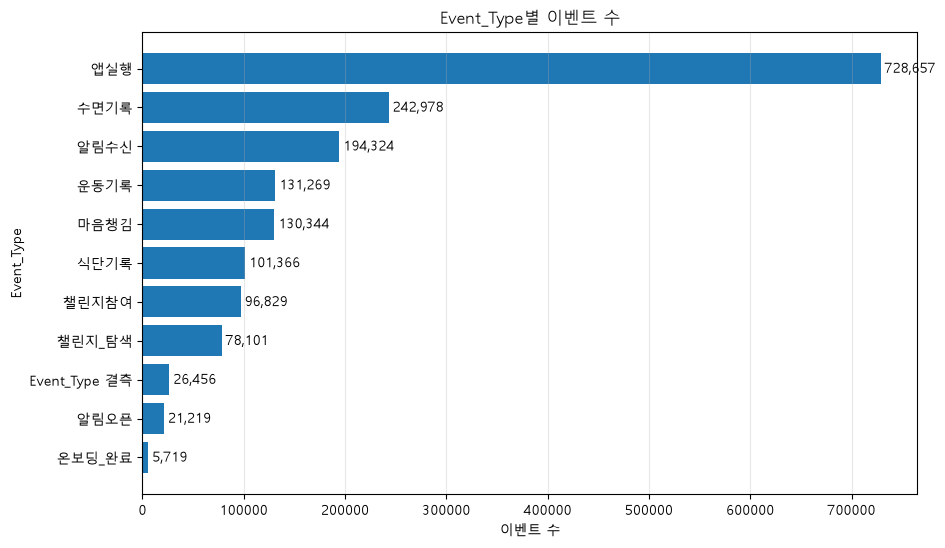

In [10]:
# Event_Type별 이벤트 수 그래프
plot_event_type = event_type_summary.sort_values("event_count")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_event_type["event_type_display"],
    plot_event_type["event_count"]
)

plt.title("Event_Type별 이벤트 수")
plt.xlabel("이벤트 수")
plt.ylabel("Event_Type")
plt.grid(axis="x", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:,}" for value in plot_event_type["event_count"]],
    padding=3
)

plt.show()

### 그래프 해석: Event_Type별 이벤트 수
이벤트 유형별 발생량을 비교

`앱실행` 이벤트는 사용자가 실제로 앱에 진입했다는 신호이므로, 리텐션 활성 판단 기준으로 사용

다른 기능 이벤트는 사용자의 행동을 보여주는 보조 지표로는 의미가 있지만, 모든 사용자가 동일하게 수행하는 행동은 아닌것으로 판별     
따라서 리텐션 계산에서는 `앱실행`만 활성 이벤트로 사용하고, 나머지 이벤트는 이후 원인 분석에서 활용한다.

## 활성 인정/제외 이벤트 수 비교

,retention_active_judgement,event_count,event_ratio
0,활성 인정,728657,41.47
1,활성 제외,1028605,58.53


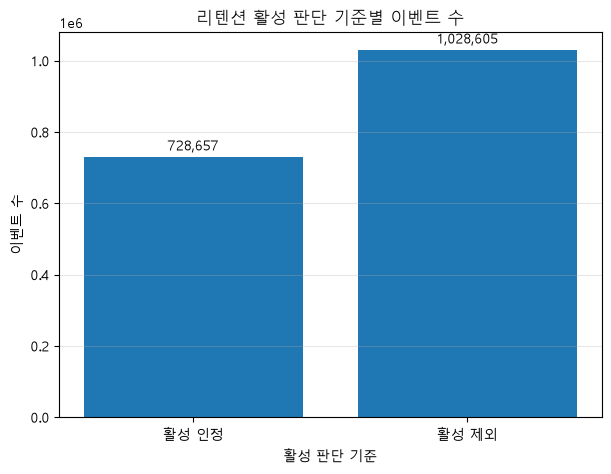

In [11]:
active_judgement_summary = (
    event_type_summary
    .groupby("retention_active_judgement", as_index=False)
    .agg(event_count=("event_count", "sum"))
)

active_judgement_summary["event_ratio"] = (
    active_judgement_summary["event_count"]
    / active_judgement_summary["event_count"].sum()
    * 100
).round(2)

display(active_judgement_summary)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    active_judgement_summary["retention_active_judgement"],
    active_judgement_summary["event_count"]
)

plt.title("리텐션 활성 판단 기준별 이벤트 수")
plt.xlabel("활성 판단 기준")
plt.ylabel("이벤트 수")
plt.grid(axis="y", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:,}" for value in active_judgement_summary["event_count"]],
    padding=3
)

plt.show()

### 그래프 해석: 활성 인정/제외 이벤트 수

전체 이벤트 중 리텐션 활성 판단에 직접 사용하는 이벤트는 `앱실행`       
그 외 이벤트는 기능 사용, 알림 반응, 온보딩 완료 등으로 구성되어 있어 리텐션의 원인을 해석하는 보조 지표로 활용한다.

즉, 리텐션 계산에서는 `앱실행` 여부만 사용하고, 다른 이벤트들은 이후 세부 행동 패턴 분석에서 따로 비교한다.

## 기준 결정
이번 리텐션 분석에서는 **해당 일자에 `앱실행` 이벤트가 존재하는 사용자**를 활성 유저로 정의

`앱실행`은 사용자가 실제로 앱에 진입했다는 가장 직접적인 신호이나       
기록, 챌린지, 온보딩 완료 이벤트는 특정 기능을 사용한 경우에만 발생하므로, 전체 사용자에게 공통 적용되는 활성 기준으로 보기 어렵다.

따라서 이후 D0/D3/D7/D30 리텐션 계산에서는 목표일에 `앱실행` 이벤트가 있으면 retained = 1, 없으면 retained = 0으로 판단한다.

# 기준 3: 알림 이벤트 제외 기준 확인
`알림수신`, `알림오픈`은 사용자가 앱 안에서 직접 수행한 행동이라기보다 앱 밖 OS 알림 환경에서 발생하는 이벤트이다.  
따라서 이번 리텐션 분석에서는 알림 이벤트를 **활성 유저 판단 기준에서 제외**한다.

다만 알림 이벤트는 사용자의 반응을 보여주는 중요한 보조 지표이므로, 이후 리텐션 원인 분석에서는 별도로 활용한다.

## 3-1. 알림 이벤트 발생 규모 확인
먼저 `알림수신`, `알림오픈` 이벤트가 전체 로그에서 어느 정도 규모로 존재하는지 확인

,event_type_display,event_count,user_count,retention_active_judgement,exclude_reason
4,알림수신,194324,8139,활성 제외,앱 밖 OS 알림 이벤트
5,알림오픈,21219,5127,활성 제외,앱 밖 OS 알림 이벤트


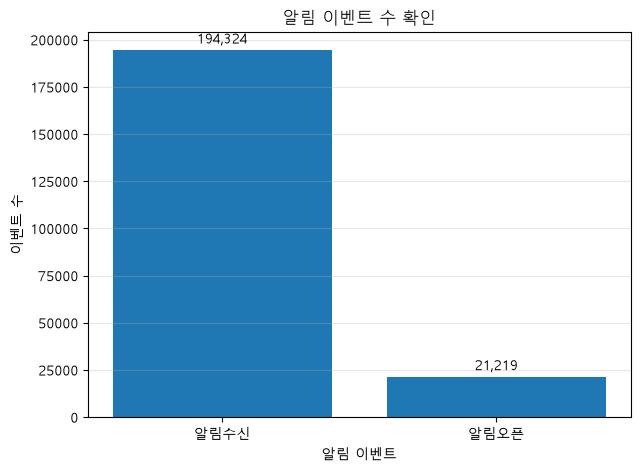

In [12]:
notification_events = ["알림수신", "알림오픈"]

notification_event_check = (
    event_type_summary
    .query("event_type_display in @notification_events")
    .loc[:, [
        "event_type_display",
        "event_count",
        "user_count",
        "retention_active_judgement",
        "exclude_reason"
    ]]
    .sort_values("event_type_display")
)

display(notification_event_check)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    notification_event_check["event_type_display"],
    notification_event_check["event_count"]
)

plt.title("알림 이벤트 수 확인")
plt.xlabel("알림 이벤트")
plt.ylabel("이벤트 수")
plt.grid(axis="y", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:,}" for value in notification_event_check["event_count"]],
    padding=3
)

plt.show()

### 그래프 해석: 알림 이벤트 수

`알림수신`과 `알림오픈`은 알림 관련 행동을 보여주는 이벤트 
하지만 이 이벤트들은 앱 밖 OS 알림 환경에서 발생할 수 있으므로, 사용자가 앱에 직접 들어온 행동으로 보기는 어렵다.

따라서 리텐션 계산에서는 제외하고, 이후 알림 반응이 리텐션과 관련 있는지 확인하는 보조 지표로 활용

## 3-2. 알림 이벤트의 Session_ID 결측 확인

과제 설명상 알림 이벤트는 앱 밖에서 발생하므로 `Session_ID`가 없는 것이 정상        
따라서 알림 이벤트의 `Session_ID` 결측률을 확인해, 알림 이벤트를 앱 내부 활동으로 보기 어려운지 점검한다.

,event_group,event_count,user_count,session_missing_count,session_missing_ratio
0,그 외 이벤트,1541719,12453,25959,1.68
1,알림 이벤트,215543,8139,215543,100.00


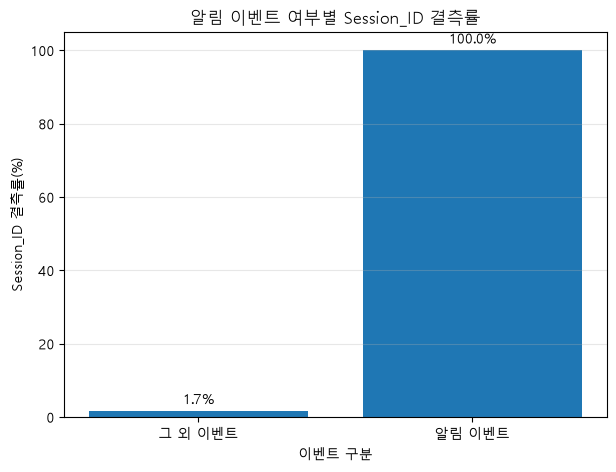

In [13]:
notification_session_summary = (
    event_log
    .assign(
        is_notification_event=event_log["event_type"].isin(notification_events),
        is_session_missing=event_log["session_id"].isna()
    )
    .groupby("is_notification_event", as_index=False)
    .agg(
        event_count=("user_id", "size"),
        user_count=("user_id", "nunique"),
        session_missing_count=("is_session_missing", "sum")
    )
)

notification_session_summary["session_missing_ratio"] = (
    notification_session_summary["session_missing_count"]
    / notification_session_summary["event_count"]
    * 100
).round(2)

notification_session_summary["event_group"] = np.where(
    notification_session_summary["is_notification_event"],
    "알림 이벤트",
    "그 외 이벤트"
)

notification_session_summary = notification_session_summary[[
    "event_group",
    "event_count",
    "user_count",
    "session_missing_count",
    "session_missing_ratio"
]]

display(notification_session_summary)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    notification_session_summary["event_group"],
    notification_session_summary["session_missing_ratio"]
)

plt.title("알림 이벤트 여부별 Session_ID 결측률")
plt.xlabel("이벤트 구분")
plt.ylabel("Session_ID 결측률(%)")
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in notification_session_summary["session_missing_ratio"]],
    padding=3
)

plt.show()

### 그래프 해석: Session_ID 결측률

알림 이벤트는 `Session_ID` 결측률이 높게 나타난다.      
이는 알림 이벤트가 앱 내부 세션에서 발생한 행동이 아니라, 앱 밖 OS 알림 환경에서 발생한 이벤트라는 설명과 일치한다.

따라서 `알림수신`, `알림오픈`은 리텐션 활성 판단에서는 제외하는 것이 적절하다.

## 기준 결정

이번 리텐션 분석에서는 `알림수신`, `알림오픈` 이벤트를 **활성 유저 판단에서 제외**한다.

- `앱실행`: 실제 앱 진입으로 보고 활성 판단에 사용
- `알림수신`, `알림오픈`: 앱 밖 OS 알림 이벤트이므로 활성 판단에서 제외
- 알림 이벤트: 이후 알림 반응과 리텐션 관계를 보는 보조 지표로 활용

# 기준 4: 로그 수집 장애 기간 플래그 확인
- 로그 수집 장애 기간: **2025-03-10 ~ 2025-03-14**
- `final_preprocessed_v1.ipynb`에서 이미 생성된 `is_log_issue_period` 컬럼을 사용
- `is_log_issue_period` 사용

다만 장애 기간 데이터를 삭제하면 실제로 남아 있는 이벤트까지 함께 사라질 수 있다.  
따라서 이미 전처리 단계에서 생성한 `is_log_issue_period` 플래그를 그대로 사용하고, 이후 분석에서 해석 주의 구간으로 관리한다.

## 4-1. 리텐션 분석용 이벤트 기준 테이블 생성

리텐션 기준 확인을 위해 이벤트 로그에 사용자 프로필 정보를 결합한다.  
여기서는 기존 전처리에서 만든 `is_log_issue_period`를 다시 만들지 않고 그대로 사용한다.

추가로 아래 컬럼만 생성한다.

| 컬럼 | 의미 |
|---|---|
| `event_day_from_signup` | 가입일 기준 이벤트 발생 경과일 |
| `is_retention_active_event` | 리텐션 활성 판단에 사용할 `앱실행` 여부 |
| `is_notification_event` | 알림 이벤트 여부 |
| `is_event_before_signup` | 가입일 이전 이벤트 여부 |


In [14]:
profile_for_merge = user_profile[[
    "user_id",
    "signup_day",
    "signup_month",
    "is_no_event_user",
    "is_signup_log_issue_period"
]].copy()

event_log_retention_base = event_log.merge(
    profile_for_merge,
    on="user_id",
    how="left"
)

event_log_retention_base["event_day_from_signup"] = (
    event_log_retention_base["event_date"] - event_log_retention_base["signup_day"]
).dt.days

event_log_retention_base["is_retention_active_event"] = (
    event_log_retention_base["event_type"].eq("앱실행")
)

event_log_retention_base["is_notification_event"] = (
    event_log_retention_base["event_type"].isin(["알림수신", "알림오픈"])
)

event_log_retention_base["is_event_before_signup"] = (
    event_log_retention_base["event_day_from_signup"].lt(0)
)

retention_base_check = pd.DataFrame({
    "항목": [
        "이벤트 로그 행 수",
        "프로필과 매칭되지 않은 이벤트 수",
        "가입일 이전 이벤트 수",
        "리텐션 활성 이벤트 수",
        "알림 이벤트 수",
        "로그 장애 기간 이벤트 수"
    ],
    "값": [
        len(event_log_retention_base),
        int(event_log_retention_base["signup_day"].isna().sum()),
        int(event_log_retention_base["is_event_before_signup"].sum()),
        int(event_log_retention_base["is_retention_active_event"].sum()),
        int(event_log_retention_base["is_notification_event"].sum()),
        int(event_log_retention_base["is_log_issue_period"].sum())
    ]
})

display(retention_base_check)
display(event_log_retention_base.head())

,항목,값
0,이벤트 로그 행 수,1757262
1,프로필과 매칭되지 않은 이벤트 수,0
2,가입일 이전 이벤트 수,0
3,리텐션 활성 이벤트 수,728657
4,알림 이벤트 수,215543
5,로그 장애 기간 이벤트 수,20862


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,event_day_from_signup,is_retention_active_event,is_notification_event,is_event_before_signup
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,True,False,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False,2025-01-25,2025-01,False,False,0,False,True,False


### 표 해석: 리텐션 분석용 이벤트 기준 테이블

리텐션 분석에 사용할 기준 컬럼이 정상적으로 만들어졌는지 확인        
특히 `is_log_issue_period`는 새로 생성한 값이 아니라, 전처리 완료 데이터에 있는 기존 플래그를 사용

이후 리텐션 계산에서는 `is_retention_active_event`가 True인 `앱실행` 이벤트만 활성 판단에 사용

## 4-2. 로그 장애 기간 이벤트 분포 확인

장애 기간에 실제 이벤트가 얼마나 포함되어 있는지 확인

,period_type,event_count,user_count,active_event_count,notification_event_count
0,정상 관측 기간,1736400,12398,719751,213044
1,로그 장애 기간,20862,2367,8906,2499


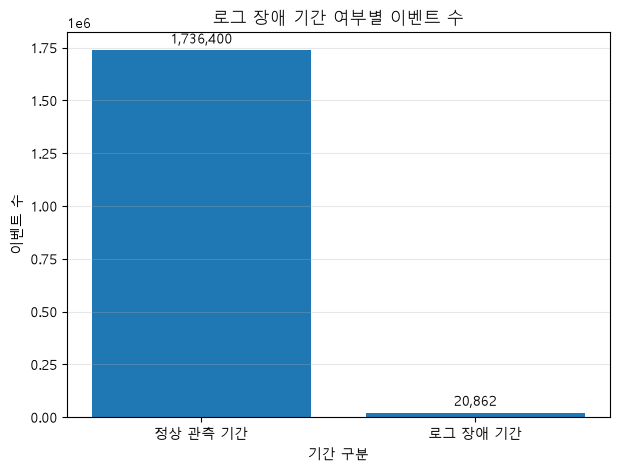

In [15]:
log_issue_event_summary = (
    event_log_retention_base
    .groupby("is_log_issue_period", as_index=False)
    .agg(
        event_count=("user_id", "size"),
        user_count=("user_id", "nunique"),
        active_event_count=("is_retention_active_event", "sum"),
        notification_event_count=("is_notification_event", "sum")
    )
)

log_issue_event_summary["period_type"] = np.where(
    log_issue_event_summary["is_log_issue_period"],
    "로그 장애 기간",
    "정상 관측 기간"
)

log_issue_event_summary = log_issue_event_summary[[
    "period_type",
    "event_count",
    "user_count",
    "active_event_count",
    "notification_event_count"
]]

display(log_issue_event_summary)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    log_issue_event_summary["period_type"],
    log_issue_event_summary["event_count"]
)

plt.title("로그 장애 기간 여부별 이벤트 수")
plt.xlabel("기간 구분")
plt.ylabel("이벤트 수")
plt.grid(axis="y", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:,}" for value in log_issue_event_summary["event_count"]],
    padding=3
)

plt.show()

### 그래프 해석: 로그 장애 기간 여부별 이벤트 수

대부분의 이벤트는 정상 관측 기간에 포함된다.        
다만 로그 장애 기간에도 이벤트가 일부 존재하므로, 해당 기간을 완전히 삭제하면 실제 관측된 행동까지 제거될 수 있다.

따라서 장애 기간은 삭제하지 않고, 플래그를 활용해 이후 분석에서 해석 주의 구간으로 처리한다.

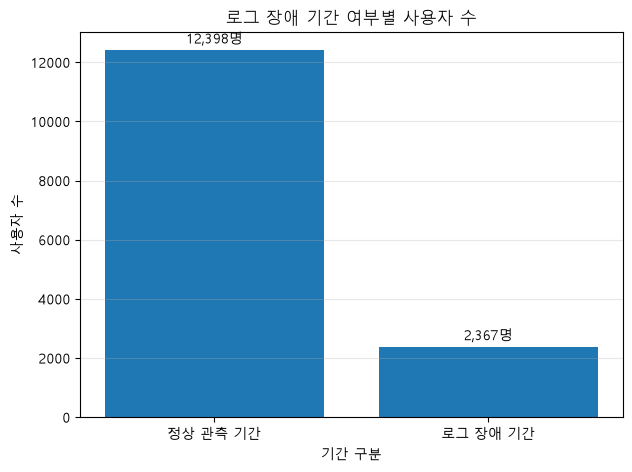

In [16]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    log_issue_event_summary["period_type"],
    log_issue_event_summary["user_count"]
)

plt.title("로그 장애 기간 여부별 사용자 수")
plt.xlabel("기간 구분")
plt.ylabel("사용자 수")
plt.grid(axis="y", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:,}명" for value in log_issue_event_summary["user_count"]],
    padding=3
)

plt.show()

### 그래프 해석: 로그 장애 기간 여부별 사용자 수

로그 장애 기간과 관련된 사용자가 존재한다.      
따라서 이 기간에 활동이 없거나 적게 보이는 사용자를 단순 이탈 사용자로 판단하면 해석이 왜곡될 수 있다.

이후 D0/D3/D7/D30 목표일이 장애 기간에 걸리는 사용자는 별도 플래그로 구분해 확인한다.

## 4-3. 날짜별 이벤트 수와 장애 기간 확인

날짜별 이벤트 수 흐름에서 장애 기간이 어느 위치에 있는지 확인한다.      

,event_date,event_count,user_count,active_event_count
0,2025-01-01,665,65,237
1,2025-01-02,1239,140,473
2,2025-01-03,1665,197,620
3,2025-01-04,1950,252,743
4,2025-01-05,2288,297,889


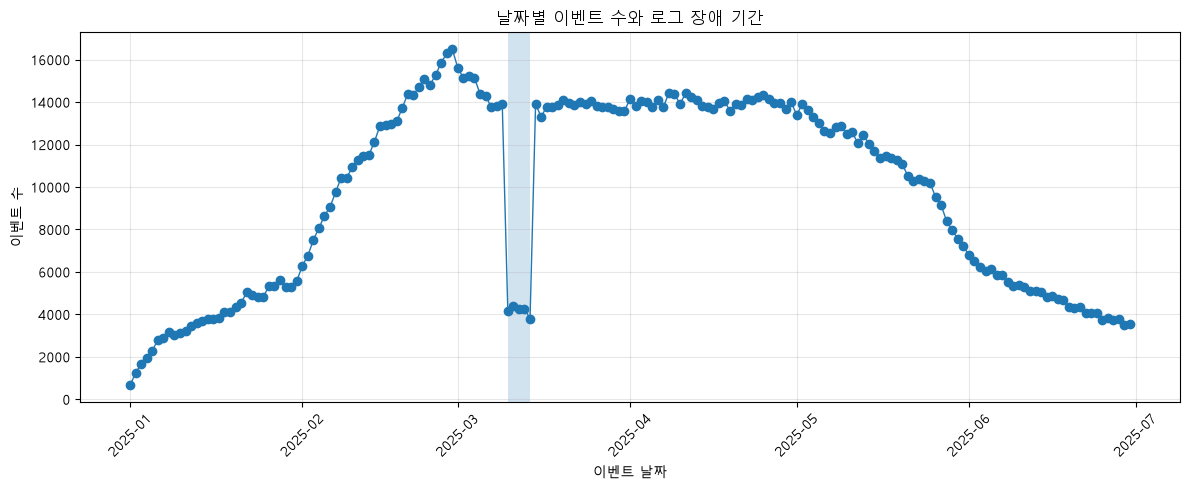

In [17]:
daily_event_summary = (
    event_log_retention_base
    .groupby("event_date", as_index=False)
    .agg(
        event_count=("user_id", "size"),
        user_count=("user_id", "nunique"),
        active_event_count=("is_retention_active_event", "sum")
    )
)

display(daily_event_summary.head())

plt.figure(figsize=(12, 5))

plt.plot(
    daily_event_summary["event_date"],
    daily_event_summary["event_count"],
    marker="o",
    linewidth=1
)

plt.axvspan(issue_start, issue_end, alpha=0.2)

plt.title("날짜별 이벤트 수와 로그 장애 기간")
plt.xlabel("이벤트 날짜")
plt.ylabel("이벤트 수")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 그래프 해석: 날짜별 이벤트 수와 장애 기간

음영으로 표시된 구간은 로그 수집 장애 기간
해당 기간의 이벤트 수는 정상 관측 기간과 동일한 기준으로 해석하기 어렵다.

따라서 이후 리텐션 분석에서는 목표일이 이 구간에 포함되는 사용자를 별도로 표시하고, 필요하면 포함/제외 결과를 함께 비교하는 것이 필요로 하다.

## 기준 결정
로그 수집 장애 기간은 삭제하지 않고 **플래그로 관리**한다.

- 장애 기간: 2025-03-10 ~ 2025-03-14
- 이벤트 기준 플래그: `is_log_issue_period`
- 처리 방식: 삭제하지 않고 해석 주의 구간으로 표시
- 이후 리텐션 분석: D0/D3/D7/D30 목표일이 장애 기간에 걸리는 사용자를 별도 플래그로 확인

즉, 장애 기간에 활동이 없다고 해서 무조건 이탈로 단정하지 않고, 데이터 품질 이슈 가능성을 함께 고려한다.

# 기준 5: D0/D3/D7/D30 목표일 산정 가능 여부 확인
리텐션을 계산하려면 각 사용자별로 목표일이 필요하다.  
예를 들어 D7 리텐션은 `가입일 + 7일`에 해당하는 날짜에 앱실행 이벤트가 있는지 확인하는 방식이다.

다만 목표일이 이벤트 관측 기간 밖에 있거나, 로그 수집 장애 기간과 겹치면 리텐션 해석에 주의가 필요함

## 사용자별 리텐션 목표일 생성

In [18]:
# 사용자별 D0/D3/D7/D30 목표일 생성

retention_day_df = pd.DataFrame({
    "retention_day": retention_days_list
})

user_retention_targets = (
    user_profile[[
        "user_id",
        "signup_day",
        "signup_month",
        "is_no_event_user",
        "is_signup_log_issue_period"
    ]]
    .merge(retention_day_df, how="cross")
)

user_retention_targets["target_date"] = (
    user_retention_targets["signup_day"]
    + pd.to_timedelta(user_retention_targets["retention_day"], unit="D")
)

user_retention_targets["retention_label"] = (
    "D" + user_retention_targets["retention_day"].astype(str)
)

event_observation_start = event_log["event_date"].min()
event_observation_end = event_log["event_date"].max()

user_retention_targets["is_target_observable"] = (
    user_retention_targets["target_date"].between(
        event_observation_start,
        event_observation_end
    )
)

user_retention_targets["is_target_log_issue_period"] = (
    user_retention_targets["target_date"].between(
        issue_start,
        issue_end
    )
)

display(user_retention_targets.head())

,user_id,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,retention_day,target_date,retention_label,is_target_observable,is_target_log_issue_period
0,U0000001,2025-01-25,2025-01,False,False,0,2025-01-25,D0,True,False
1,U0000001,2025-01-25,2025-01,False,False,3,2025-01-28,D3,True,False
2,U0000001,2025-01-25,2025-01,False,False,7,2025-02-01,D7,True,False
3,U0000001,2025-01-25,2025-01,False,False,30,2025-02-24,D30,True,False
4,U0000002,2025-05-06,2025-05,False,False,0,2025-05-06,D0,True,False


## 목표일 산정 가능 여부 요약표

In [19]:
target_observable_summary = (
    user_retention_targets
    .groupby(["retention_day", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        observable_user_count=("is_target_observable", "sum"),
        log_issue_target_user_count=("is_target_log_issue_period", "sum")
    )
    .sort_values("retention_day")
)

target_observable_summary["observable_rate"] = (
    target_observable_summary["observable_user_count"]
    / target_observable_summary["target_user_count"]
    * 100
).round(2)

target_observable_summary["log_issue_target_rate"] = (
    target_observable_summary["log_issue_target_user_count"]
    / target_observable_summary["target_user_count"]
    * 100
).round(2)

target_observable_summary = target_observable_summary[[
    "retention_label",
    "target_user_count",
    "observable_user_count",
    "observable_rate",
    "log_issue_target_user_count",
    "log_issue_target_rate"
]]

display(target_observable_summary)

,retention_label,target_user_count,observable_user_count,observable_rate,log_issue_target_user_count,log_issue_target_rate
0,D0,12500,12500,100.0,341,2.73
1,D3,12500,12500,100.0,341,2.73
2,D7,12500,12500,100.0,368,2.94
3,D30,12500,12500,100.0,771,6.17


## 5-1. 리텐션 목표일 관측 가능률 확인
D0/D3/D7/D30 목표일이 이벤트 관측 기간 안에 들어오는지 확인

목표일이 관측 기간 밖이면 해당 사용자의 리텐션 여부를 판단할 수 없으므로, 이후 리텐션 계산에서 제외하거나 별도로 관리가 필요

### 목표일 관측 가능률 그래프

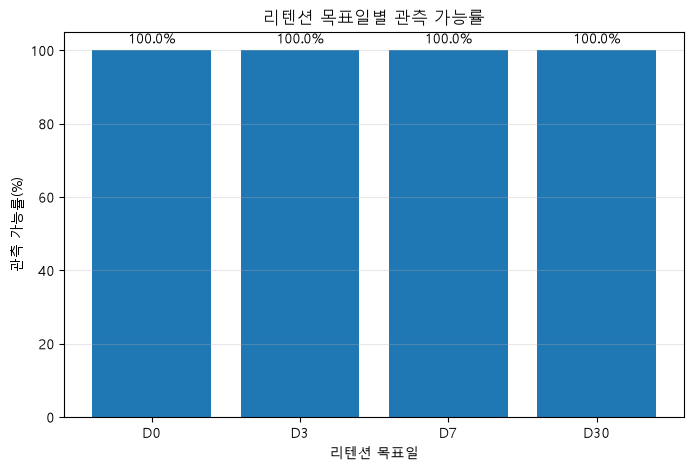

In [20]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    target_observable_summary["retention_label"],
    target_observable_summary["observable_rate"]
)

plt.title("리텐션 목표일별 관측 가능률")
plt.xlabel("리텐션 목표일")
plt.ylabel("관측 가능률(%)")
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in target_observable_summary["observable_rate"]],
    padding=3
)

plt.show()

### 그래프 해석: 리텐션 목표일별 관측 가능률

D0, D3, D7, D30 모두 관측 가능률이 100%로 확인된다.
즉, 현재 데이터 기간 안에서 각 리텐션 목표일은 모두 산정 가능

## 5-2. 리텐션 목표일과 로그 장애 기간 중복 확인
목표일이 로그 수집 장애 기간과 겹치면, 실제로 사용자가 앱을 실행했더라도 이벤트가 누락되었을 가능성이 있다.


### 목표일이 장애 기간에 걸리는 사용자 수 그래프

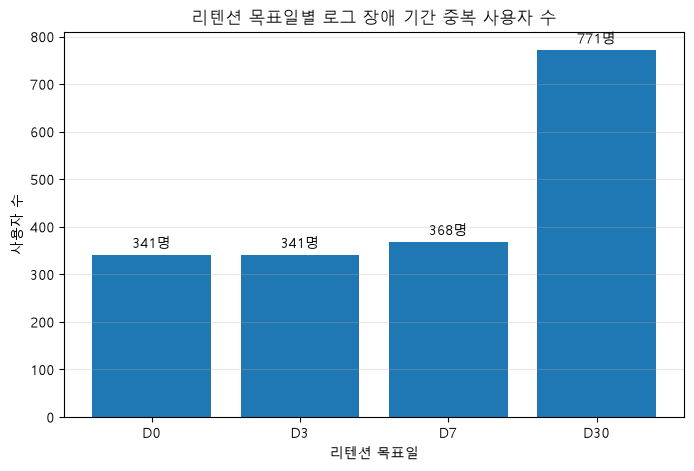

In [21]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    target_observable_summary["retention_label"],
    target_observable_summary["log_issue_target_user_count"]
)

plt.title("리텐션 목표일별 로그 장애 기간 중복 사용자 수")
plt.xlabel("리텐션 목표일")
plt.ylabel("사용자 수")
plt.grid(axis="y", alpha=0.3)

plt.bar_label(
    bars,
    labels=[f"{value:,}명" for value in target_observable_summary["log_issue_target_user_count"]],
    padding=3
)

plt.show()

### 그래프 해석: 리텐션 목표일별 로그 장애 기간 중복 사용자 수

일부 사용자의 리텐션 목표일이 로그 수집 장애 기간과 겹친다.
특히 D30에서 장애 기간과 겹치는 사용자가 가장 많다.

이 사용자는 목표일에 앱실행 로그가 없더라도 실제 미사용자라고 단정하기 어렵기 때문에, 이후 리텐션 해석 시 주의가 필요하다.

### 가입월별 목표일 장애기간 중복 확인

In [22]:
target_issue_by_signup_month = (
    user_retention_targets
    .groupby(["signup_month", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        log_issue_target_user_count=("is_target_log_issue_period", "sum")
    )
)

target_issue_by_signup_month["log_issue_target_rate"] = (
    target_issue_by_signup_month["log_issue_target_user_count"]
    / target_issue_by_signup_month["target_user_count"]
    * 100
).round(2)

target_issue_pivot = target_issue_by_signup_month.pivot(
    index="signup_month",
    columns="retention_label",
    values="log_issue_target_user_count"
)

target_issue_pivot = target_issue_pivot[["D0", "D3", "D7", "D30"]]

display(target_issue_pivot)

retention_label,D0,D3,D7,D30
signup_month,,,,
2025-01,0,0,0,0
2025-02,0,0,0,771
2025-03,341,341,368,0
2025-04,0,0,0,0
2025-05,0,0,0,0


### 가입월 × 목표일 장애기간 중복 히트맵

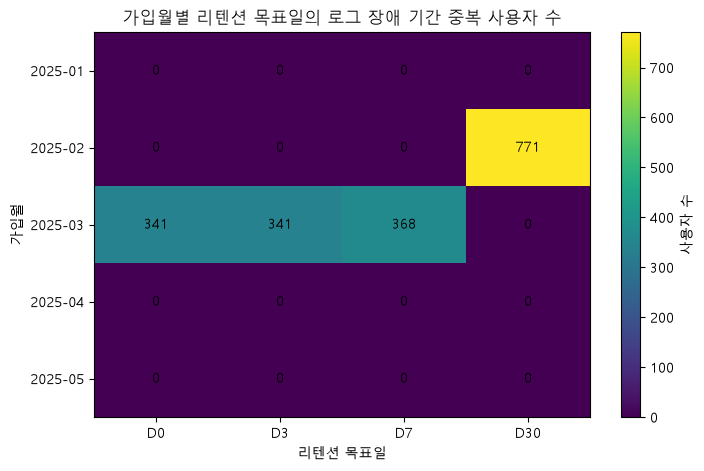

In [23]:
plt.figure(figsize=(8, 5))

plt.imshow(target_issue_pivot, aspect="auto")

plt.title("가입월별 리텐션 목표일의 로그 장애 기간 중복 사용자 수")
plt.xlabel("리텐션 목표일")
plt.ylabel("가입월")

plt.xticks(
    ticks=np.arange(len(target_issue_pivot.columns)),
    labels=target_issue_pivot.columns
)

plt.yticks(
    ticks=np.arange(len(target_issue_pivot.index)),
    labels=target_issue_pivot.index
)

for row_idx in range(target_issue_pivot.shape[0]):
    for col_idx in range(target_issue_pivot.shape[1]):
        value = target_issue_pivot.iloc[row_idx, col_idx]
        plt.text(
            col_idx,
            row_idx,
            f"{int(value):,}",
            ha="center",
            va="center"
        )

plt.colorbar(label="사용자 수")
plt.show()

### 그래프 해석: 가입월별 장애 기간 중복 목표일

로그 장애 기간의 영향은 특정 가입월과 목표일에 집중되어 있다.
2월 가입자는 D30, 3월 가입자는 D0/D3/D7 목표일 일부가 장애 기간과 겹친다.

따라서 이후 코호트 리텐션 분석에서는 2월 D30과 3월 D0/D3/D7 값을 해석할 때 주의해야 한다.

## 기준 결정

D0/D3/D7/D30 목표일은 모두 이벤트 관측 기간 안에 포함되므로, 리텐션 분석 대상으로 사용한다.

다만 일부 목표일은 로그 수집 장애 기간과 겹친다.  
해당 사용자를 삭제하지는 않고, `is_target_log_issue_period` 플래그로 관리한다.

이후 리텐션 분석에서는 기본 리텐션율을 계산하되, 장애 기간과 겹치는 구간은 해석 시 주의한다.  
특히 2월 가입자의 D30, 3월 가입자의 D0/D3/D7 리텐션은 로그 누락 가능성을 함께 고려한다.

즉, 이후 리텐션 분석에서는 아래 기준을 따른다.

| 구분 | 처리 기준 |
|---|---|
| 목표일 관측 가능 | 리텐션 산정 가능 |
| 목표일 관측 불가 | 이번 데이터에서는 없음. 발생 시 리텐션 산정 제외 또는 별도 관리 |
| 목표일이 장애 기간과 겹침 | 삭제하지 않고 플래그 처리 |
| 리텐션 목표일 | D0, D3, D7, D30 |

# 기준 6: 월별 가입 코호트 기준 분석 가능 범위 확인

앞에서는 D0/D3/D7/D30 목표일을 **가입월 코호트 기준**으로 나눠서 확인

월별 가입자 집단마다 리텐션 목표일이 로그 장애 기간과 겹치는 정도가 다를 수 있다.  

## 6-1. 가입월 × 리텐션 목표일별 산정 가능 상태 확인

각 가입월 코호트에 대해 D0/D3/D7/D30 목표일이 정상적으로 산정 가능한지 확인

| 상태 | 의미 |
|---|---|
| 정상 산정 가능 | 목표일이 관측 기간 안에 있고, 로그 장애 기간과 겹치지 않음 |
| 장애기간 중복 | 목표일이 로그 수집 장애 기간과 겹침 |
| 관측 불가 | 목표일이 이벤트 관측 기간 밖에 있음 |


In [24]:
# 가입월 × 리텐션 목표일별 산정 가능 상태 확인

user_retention_targets["retention_target_status"] = np.select(
    [
        ~user_retention_targets["is_target_observable"],
        user_retention_targets["is_target_log_issue_period"],
        user_retention_targets["is_target_observable"] & ~user_retention_targets["is_target_log_issue_period"]
    ],
    [
        "관측 불가",
        "장애기간 중복",
        "정상 산정 가능"
    ],
    default="확인 필요"
)

cohort_target_summary = (
    user_retention_targets
    .groupby(["signup_month", "retention_day", "retention_label"], as_index=False)
    .agg(
        cohort_user_count=("user_id", "nunique"),
        observable_user_count=("is_target_observable", "sum"),
        log_issue_target_user_count=("is_target_log_issue_period", "sum")
    )
)

cohort_target_summary["normal_target_user_count"] = (
    cohort_target_summary["observable_user_count"]
    - cohort_target_summary["log_issue_target_user_count"]
)

cohort_target_summary["observable_rate"] = (
    cohort_target_summary["observable_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

cohort_target_summary["normal_target_rate"] = (
    cohort_target_summary["normal_target_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

cohort_target_summary["log_issue_target_rate"] = (
    cohort_target_summary["log_issue_target_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

cohort_target_summary["retention_label"] = pd.Categorical(
    cohort_target_summary["retention_label"],
    categories=["D0", "D3", "D7", "D30"],
    ordered=True
)

cohort_target_summary = cohort_target_summary.sort_values(
    ["signup_month", "retention_label"]
)

display(cohort_target_summary)


,signup_month,retention_day,retention_label,cohort_user_count,observable_user_count,log_issue_target_user_count,normal_target_user_count,observable_rate,normal_target_rate,log_issue_target_rate
0,2025-01,0,D0,2124,2124,0,2124,100.0,100.00,0.00
1,2025-01,3,D3,2124,2124,0,2124,100.0,100.00,0.00
2,2025-01,7,D7,2124,2124,0,2124,100.0,100.00,0.00
3,2025-01,30,D30,2124,2124,0,2124,100.0,100.00,0.00
4,2025-02,0,D0,4384,4384,0,4384,100.0,100.00,0.00
5,2025-02,3,D3,4384,4384,0,4384,100.0,100.00,0.00
6,2025-02,7,D7,4384,4384,0,4384,100.0,100.00,0.00
7,2025-02,30,D30,4384,4384,771,3613,100.0,82.41,17.59
8,2025-03,0,D0,2122,2122,341,1781,100.0,83.93,16.07
9,2025-03,3,D3,2122,2122,341,1781,100.0,83.93,16.07


## 6-2. 가입월 × 리텐션 목표일 정상 산정 가능률 히트맵

retention_label,D0,D3,D7,D30
signup_month,,,,
2025-01,100.00,100.00,100.00,100.00
2025-02,100.00,100.00,100.00,82.41
2025-03,83.93,83.93,82.66,100.00
2025-04,100.00,100.00,100.00,100.00
2025-05,100.00,100.00,100.00,100.00


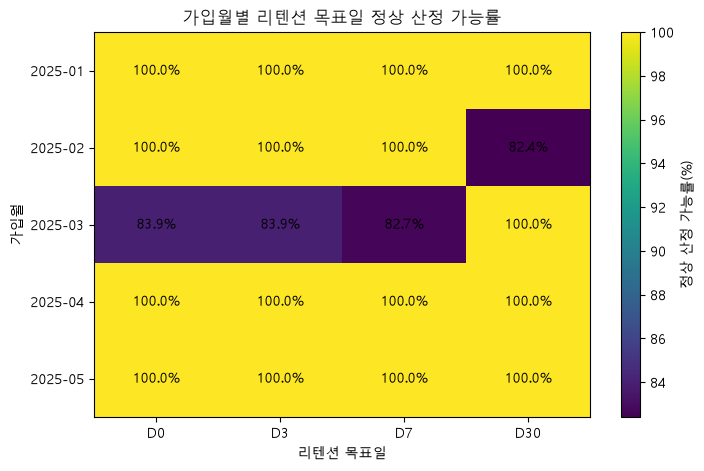

In [25]:
normal_rate_matrix = cohort_target_summary.pivot(
    index="signup_month",
    columns="retention_label",
    values="normal_target_rate"
)

normal_rate_matrix = normal_rate_matrix[["D0", "D3", "D7", "D30"]]

display(normal_rate_matrix)

plt.figure(figsize=(8, 5))
plt.imshow(normal_rate_matrix, aspect="auto")

plt.title("가입월별 리텐션 목표일 정상 산정 가능률")
plt.xlabel("리텐션 목표일")
plt.ylabel("가입월")

plt.xticks(
    ticks=np.arange(len(normal_rate_matrix.columns)),
    labels=normal_rate_matrix.columns
)

plt.yticks(
    ticks=np.arange(len(normal_rate_matrix.index)),
    labels=normal_rate_matrix.index
)

for row_idx in range(normal_rate_matrix.shape[0]):
    for col_idx in range(normal_rate_matrix.shape[1]):
        value = normal_rate_matrix.iloc[row_idx, col_idx]
        plt.text(
            col_idx,
            row_idx,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

plt.colorbar(label="정상 산정 가능률(%)")
plt.show()


### 그래프 해석: 가입월별 정상 산정 가능률
대부분의 가입월과 목표일은 정상 산정 가능률이 높아 리텐션 비교에 사용할 수 있다.

다만 일부 셀은 로그 장애 기간과 겹치면서 정상 산정 가능률이 낮아진다.        
이 셀은 실제 리텐션 하락이라기보다 로그 누락 가능성이 섞여 있을 수 있으므로, 최종 해석에서 주의해야 한다.

## 6-3. 가입월 × 리텐션 목표일 장애기간 중복 사용자 수 확인
정상 산정 가능률이 낮아진 원인을 확인하기 위해, 가입월과 목표일별로 로그 장애 기간과 겹치는 사용자 수를 확인한다.

retention_label,D0,D3,D7,D30
signup_month,,,,
2025-01,0,0,0,0
2025-02,0,0,0,771
2025-03,341,341,368,0
2025-04,0,0,0,0
2025-05,0,0,0,0


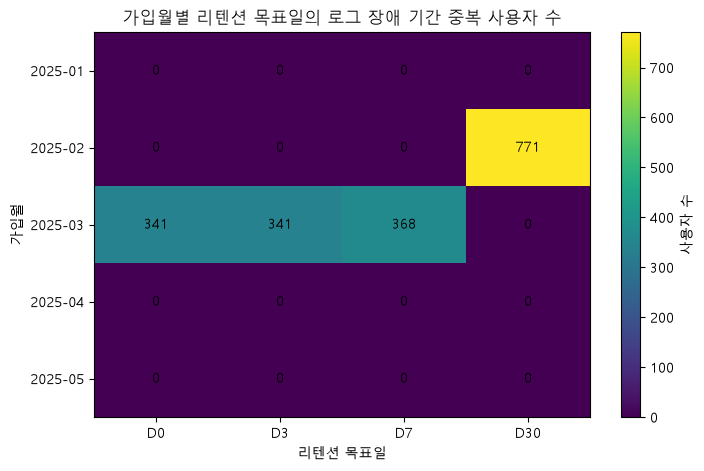

In [26]:
issue_count_matrix = cohort_target_summary.pivot(
    index="signup_month",
    columns="retention_label",
    values="log_issue_target_user_count"
)

issue_count_matrix = issue_count_matrix[["D0", "D3", "D7", "D30"]]

display(issue_count_matrix)

plt.figure(figsize=(8, 5))
plt.imshow(issue_count_matrix, aspect="auto")

plt.title("가입월별 리텐션 목표일의 로그 장애 기간 중복 사용자 수")
plt.xlabel("리텐션 목표일")
plt.ylabel("가입월")

plt.xticks(
    ticks=np.arange(len(issue_count_matrix.columns)),
    labels=issue_count_matrix.columns
)

plt.yticks(
    ticks=np.arange(len(issue_count_matrix.index)),
    labels=issue_count_matrix.index
)

for row_idx in range(issue_count_matrix.shape[0]):
    for col_idx in range(issue_count_matrix.shape[1]):
        value = issue_count_matrix.iloc[row_idx, col_idx]
        plt.text(
            col_idx,
            row_idx,
            f"{int(value):,}",
            ha="center",
            va="center"
        )

plt.colorbar(label="사용자 수")
plt.show()


### 그래프 해석: 장애기간 중복 사용자 수

장애 기간의 영향은 전체 코호트에 고르게 퍼져 있지 않고, 특정 가입월과 목표일에 집중되어 있다.

특히 2월 가입자의 D30, 3월 가입자의 D0/D3/D7 목표일은 로그 장애 기간과 겹치는 사용자가 있다.        
따라서 이 구간의 리텐션 결과는 그대로 단정하지 않고, 로그 누락 가능성을 함께 고려한다.

## 기준 결정
월별 가입 코호트 기준으로 D0/D3/D7/D30 목표일의 산정 가능 범위를 확인한 결과, 모든 가입월과 리텐션 목표일은 이벤트 관측 기간 안에 포함되어 리텐션 산정 자체는 가능하다.

다만 로그 수집 장애 기간의 영향은 특정 코호트에 집중되어 있다.  
2025년 2월 가입자는 D30 목표일 일부가 장애 기간과 겹치며, 2025년 3월 가입자는 D0/D3/D7 목표일 일부가 장애 기간과 겹친다.

따라서 이후 월별 가입 코호트 리텐션 분석에서는 전체 코호트를 사용할 수 있지만, 2월 D30과 3월 D0/D3/D7 구간은 로그 누락 가능성을 고려해 해석한다.

# D30 기준 월별 가입 코호트 점검
과제의 핵심 지표는 30일 리텐션, D30 기준으로 월별 가입 코호트가 얼마나 정상적으로 산정 가능한지 한 번 더 확인

In [27]:
d30_target_by_month = (
    cohort_target_summary
    .query("retention_label == 'D30'")
    .copy()
    .sort_values("signup_month")
)

d30_target_by_month = d30_target_by_month[[
    "signup_month",
    "cohort_user_count",
    "normal_target_user_count",
    "normal_target_rate",
    "log_issue_target_user_count",
    "log_issue_target_rate"
]]

display(d30_target_by_month)


,signup_month,cohort_user_count,normal_target_user_count,normal_target_rate,log_issue_target_user_count,log_issue_target_rate
3,2025-01,2124,2124,100.00,0,0.00
7,2025-02,4384,3613,82.41,771,17.59
11,2025-03,2122,2122,100.00,0,0.00
15,2025-04,2082,2082,100.00,0,0.00
19,2025-05,1788,1788,100.00,0,0.00


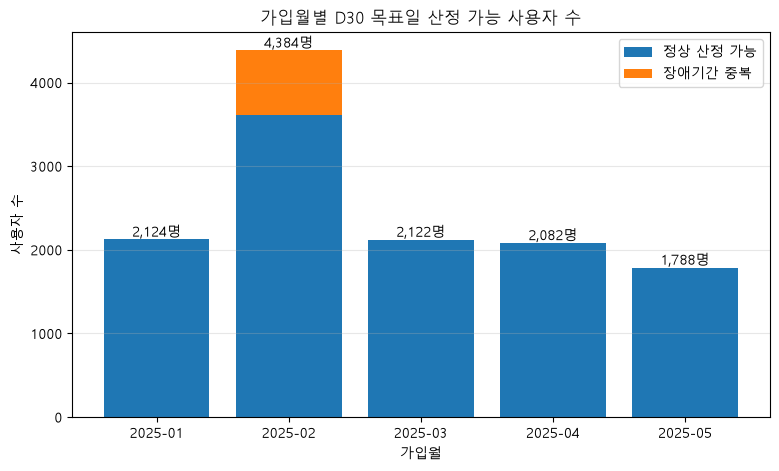

In [28]:
plt.figure(figsize=(9, 5))

bars_normal = plt.bar(
    d30_target_by_month["signup_month"],
    d30_target_by_month["normal_target_user_count"],
    label="정상 산정 가능"
)

bars_issue = plt.bar(
    d30_target_by_month["signup_month"],
    d30_target_by_month["log_issue_target_user_count"],
    bottom=d30_target_by_month["normal_target_user_count"],
    label="장애기간 중복"
)

plt.title("가입월별 D30 목표일 산정 가능 사용자 수")
plt.xlabel("가입월")
plt.ylabel("사용자 수")
plt.grid(axis="y", alpha=0.3)
plt.legend()

total_values = (
    d30_target_by_month["normal_target_user_count"]
    + d30_target_by_month["log_issue_target_user_count"]
)

for idx, total_value in enumerate(total_values):
    plt.text(
        idx,
        total_value,
        f"{int(total_value):,}명",
        ha="center",
        va="bottom"
    )

plt.show()


### 그래프 해석: 가입월별 D30 산정 가능 사용자 수

D30 목표일은 모든 가입월에서 관측 기간 안에 포함되므로 산정 자체는 가능하나     
2월 가입자의 D30 목표일 일부가 로그 장애 기간과 겹친다.

따라서 2월 코호트의 D30 리텐션은 이후 분석에서 특히 주의해서 해석해야 한다.


# 최종 기준 요약
| 구분           | 기준                                 |
| ------------ | ---------------------------------- |
| Day 0        | 가입일                                |
| 활성 유저 판단 이벤트 | 앱실행                                |
| 활성 판단 제외 이벤트 | 알림수신, 알림오픈                         |
| 로그 수집 장애 기간  | 2025-03-10 ~ 2025-03-14            |
| 장애 기간 처리     | 삭제하지 않고 플래그 처리                     |
| 코호트 기준       | 가입월(signup_month)                  |
| 리텐션 목표일      | D0, D3, D7, D30                    |
| 리텐션 판정 방식    | 가입일 + N일째 되는 날짜에 앱실행 이벤트가 있는지 확인   |
| 사용자 중복 처리    | 목표일에 앱실행이 여러 번 있어도 사용자 1명은 1명으로 계산 |
| 주의 필요 코호트    | 2월 D30, 3월 D0/D3/D7                |
